In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dill
import numpy as np
import os
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split, HalvingGridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score
from sklearnex.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import joblib
from datetime import datetime

cur_dir = os.getcwd()

In [2]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

with open(cur_dir + '\\saves\\preprocessing_pipeline.dill', 'rb') as file:
    pipe = dill.load(file)

df = pipe.transform(df)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

In [28]:
try:
    stats = joblib.load(cur_dir + '\\saves\\models_training0.pkl')
except:
    stats = pd.DataFrame(columns=['model', 'iteration', 'f1_train', 'f1_test', 'accuracy_test'])

    test_scores = joblib.load(cur_dir + '\\saves\\resampling_selection.pkl')['test_scores']
    test_scores = test_scores[test_scores['sampler'] == 'RandomOverSampler']

    for model_name in ['Nearest Neighbor', 'Decision Tree', 'Random Forest', 'MLPC']:
        f1 = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'f1'), 'value'].item()
        accuracy = test_scores.loc[(test_scores['model'] == model_name) & (test_scores['metric'] == 'accuracy'), 'value'].item()
        stats.loc[len(stats.index)] = {'model': model_name, 'iteration': 0, 'F1_test': f1, 'accuracy_test': accuracy}

stats

,model,iteration,f1_train,f1_test,accuracy_test
0,Nearest Neighbor,0,NaN,0.597887,0.994481
1,Decision Tree,0,NaN,0.784026,0.997548
2,Random Forest,0,NaN,0.850991,0.998399
3,MLPC,0,NaN,0.730688,0.996462
4,Decision Tree,1,0.772371,0.784292,0.997560
5,Decision Tree,2,0.771597,0.784292,0.997560
6,mlpc,1,0.000000,0.000000,0.994210
7,mlpc,2,0.000000,0.000000,0.994210
8,mlpc_,1,0.817457,0.839563,0.998279
9,mlpc_,2,0.817657,0.839673,0.998245


In [4]:
def gs_cv(model_name, iteration, model, params, n_jobs=12, search_type='halving'):
    if stats[(stats['model'] == model_name) & (stats['iteration'] == iteration)].shape[0] > 0:
        raise ValueError('Search with this same name already exists')

    start = datetime.now()
    cv = RepeatedStratifiedKFold(random_state=1)

    if search_type == 'grid':
        gs = GridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs, verbose=2)
    else:
        gs = HalvingGridSearchCV(model, cv=cv, param_grid=params, scoring='f1', n_jobs=n_jobs, verbose=2, aggressive_elimination=True)
    gs.fit(X_train, y_train)
    print('Best params:', gs.best_params_)
    
    pred = gs.predict(X_test)
    
    stats.loc[len(stats.index)] = [model_name, iteration, gs.best_score_, f1_score(y_test, pred), accuracy_score(y_test, pred)]
    joblib.dump(stats, cur_dir + '\\saves\\models_training.pkl')
    joblib.dump(gs, cur_dir + '\\saves\\models_training\\' + model_name + '_' + str(iteration) + '.pkl')
    
    print('\nTime:', (datetime.now() - start).seconds /60 /60)  # hours
    print('Best params:', gs.best_params_)

    print('Train set f1:', stats.loc[len(stats.index)-1, 'f1_train'])
    print('Test set f1:', stats.loc[len(stats.index)-1, 'f1_test'])
    
    print('Test set accuracy:', stats.loc[len(stats.index)-1, 'accuracy_test'])

    return gs

In [11]:
joblib.dump(stats, cur_dir + '\\saves\\models_training.pkl')

['C:\\Users\\dfskl\\Jupyter notebooks\\kaggle\\Credit-Card-Transactions-Fraud-Detection\\saves\\models_training.pkl']

In [9]:
stats.loc[(stats['model'] == 'Decision Tree') & (stats['iteration'] == 2), 'f1_train'] = 0.7715967179397006

In [5]:
stats

,model,iteration,f1_train,f1_test,accuracy_test
0,Nearest Neighbor,0,NaN,0.597887,0.994481
1,Decision Tree,0,NaN,0.784026,0.997548
2,Random Forest,0,NaN,0.850991,0.998399
3,MLPC,0,NaN,0.730688,0.996462
4,Decision Tree,1,0.772371,0.784292,0.997560
5,Decision Tree,2,0.771597,0.784292,0.997560


In [26]:
def tuneplot(model):
    ax = sns.lineplot(data=stats[stats['model'] == model], x='iteration', y='f1_test', label='Test')
    ax2 = sns.lineplot(data=stats[stats['model'] == model], x='iteration', y='f1_train', label='Train')
    ax.set_title(model + ' f1 score over hyperparameters tuning iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('F1 score')
    ax.set_xticks(range(0, stats[stats['model'] == model].shape[0]));
    #ax.legend(bbox_to_anchor=(1, 1), labels=('Test','Train', 'sdf'));


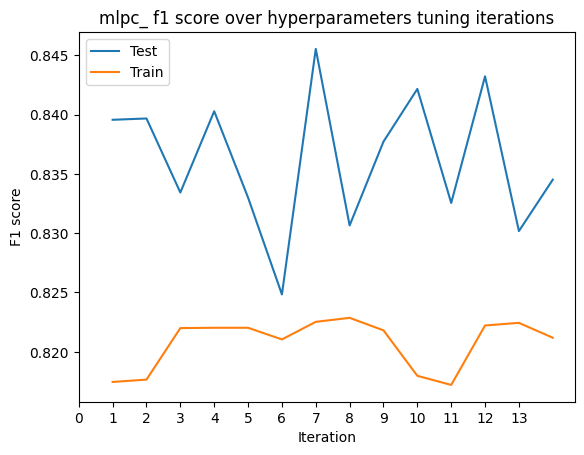

In [27]:
tuneplot('mlpc_')

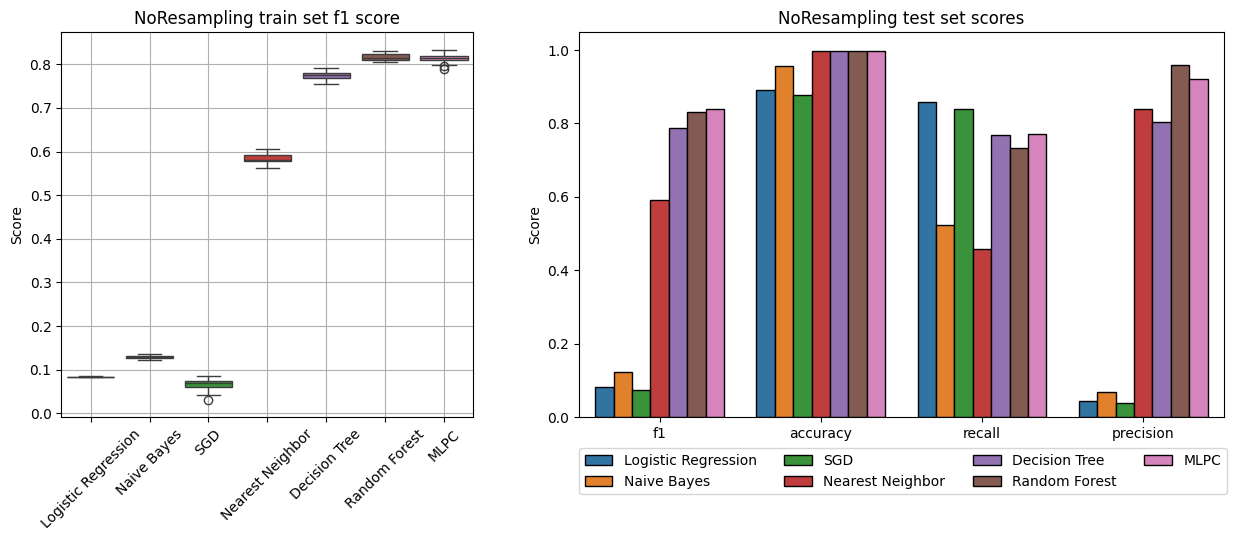

In [24]:
stats[['model', 'iteration', 'F1_test', 'accuracy_test']] 

,model,iteration,F1_test,accuracy_test
0,Nearest Neighbor,0,0.597887,0.994481
1,Decision Tree,0,0.784026,0.997548
2,Random Forest,0,0.850991,0.998399
3,MLPC,0,0.730688,0.996462
4,Decision Tree,1,0.784292,0.997560
5,Decision Tree,2,0.784292,0.997560


### Nearest Neighbor

In [ ]:
stats.loc[stats['model'] == 'Nearest Neighbor', ['model', 'iteration', 'F1_test', 'accuracy_test']] 

### Decision Tree

In [ ]:
stats.loc[stats['model'] == 'Decision Tree', ['model', 'iteration', 'F1_test', 'accuracy_test']] 

In [6]:
stats = stats[(stats['model'] != 'Decision Tree') | (stats['iteration'] != 1)]

In [20]:
dec_tree = DecisionTreeClassifier(random_state=1, class_weight='balanced').fit(X_train, y_train)

pred = dec_tree.predict(X_test)
print(f1_score(y_test, pred))
print(accuracy_score(y_test, pred))
print('Decision tree depth:', dec_tree.get_depth())

0.7842923370602672
0.9975599147358323
Decision tree depth: 104


In [17]:
params = [{
            'min_samples_split': np.linspace(2, 40, 5).astype(int),
            'min_samples_leaf': np.linspace(1, 40, 5).astype(int)
          }]

gs = gs_cv('Decision Tree', 1, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='halving')

n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 108056
max_resources_: 972506
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 25
n_resources: 108056
Fitting 50 folds for each of 25 candidates, totalling 1250 fits
----------
iter: 1
n_candidates: 9
n_resources: 324168
Fitting 50 folds for each of 9 candidates, totalling 450 fits
----------
iter: 2
n_candidates: 3
n_resources: 972504
Fitting 50 folds for each of 3 candidates, totalling 150 fits
Best params: {'min_samples_leaf': 1, 'min_samples_split': 2}

Time: 0.40194444444444444
Best params: {'min_samples_leaf': 1, 'min_samples_split': 2}
		   TP/TN/FP/FN
Train set stats(n): 5629 966877 0 0
Train set stats(%): 1.0 1.0 0.0 0.0
Test set stats(n): 1438 321940 352 439
Test set stats(%): 0.7661161427810336 0.9989078227197696 0.0010921772802303502 0.23388385721896643 

Train set cv mean f1: 0.7723714115005247
Train set f1: 1.0
Test set f1: 0.7842923370602672
Train set accuracy: 1.0
Te

In [18]:
gs.best_estimator_.get_depth()

104

In [23]:
params = [{
            'min_samples_split': range(2, 5),
            'min_samples_leaf': range(1, 5),
            'max_depth': range(90, 106, 5)
          }]

gs = gs_cv('Decision Tree', 2, DecisionTreeClassifier(random_state=1, class_weight='balanced'), params, search_type='grid')

Fitting 50 folds for each of 48 candidates, totalling 2400 fits
Best params: {'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 2}

Time: 3.315833333333333
Best params: {'max_depth': 105, 'min_samples_leaf': 1, 'min_samples_split': 2}
		   TP/TN/FP/FN
Train set stats(n): 5629 966877 0 0
Train set stats(%): 1.0 1.0 0.0 0.0
Test set stats(n): 1438 321940 352 439
Test set stats(%): 0.7661161427810336 0.9989078227197696 0.0010921772802303502 0.23388385721896643 

Train set cv mean f1: 0.7715967179397006
Train set f1: 1.0
Test set f1: 0.7842923370602672
Train set accuracy: 1.0
Test set accuracy: 0.9975599147358323


### Random Forest - ACTUAL ON MY PC

In [ ]:
stats.loc[stats['model'] == 'Random Forest', ['model', 'iteration', 'F1_test', 'accuracy_test']] 

In [29]:
forest = RandomForestClassifier(random_state=1, class_weight='balanced').fit(X_train, y_train)

array([ 100,  575, 1050, 1525, 2000])

In [ ]:
#start approx 13 53
params = [{
            'n_estimators': np.linspace(100, 2000, 5).astype(int),  
            'min_samples_split': np.linspace(5, 40, 5).astype(int),
            'min_samples_leaf': np.linspace(5, 20, 5).astype(int)
          }]

halving_gs_cv('forest_1', RandomForestClassifier(random_state=1), params, n_jobs=12)

#iter: 0
#n_candidates: 13718


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 23873
max_resources_: 1933754
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 125
n_resources: 23873
Fitting 50 folds for each of 125 candidates, totalling 6250 fits
----------
iter: 1
n_candidates: 42
n_resources: 71619
Fitting 50 folds for each of 42 candidates, totalling 2100 fits
----------
iter: 2
n_candidates: 14
n_resources: 214857
Fitting 50 folds for each of 14 candidates, totalling 700 fits
----------
iter: 3
n_candidates: 5
n_resources: 644571
Fitting 50 folds for each of 5 candidates, totalling 250 fits


In [ ]:

            'max_depth': range(10, 100, 10),

### MLPC - ACTUAL ON MY PC

In [ ]:
stats.loc[stats['model'] == 'MLPC', ['model', 'iteration', 'F1_test', 'accuracy_test']] 

In [15]:
#16 44
params = [{
            'hidden_layer_sizes': [(100, 100, 100, 100)]
          }]

gs = gs_cv('mlpc_', 1, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (100, 100, 100, 100)}

Time: 2.044166666666667
Best params: {'hidden_layer_sizes': (100, 100, 100, 100)}
Train set f1: 0.8174570613875237
Test set f1: 0.8395629672225418
Test set accuracy: 0.99827867562907


In [16]:
#18 53
params = [{
            'hidden_layer_sizes': [(60, 60, 60, 60)]
          }]

gs = gs_cv('mlpc_', 2, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (60, 60, 60, 60)}

Time: 0.9975
Best params: {'hidden_layer_sizes': (60, 60, 60, 60)}
Train set f1: 0.8176566200841083
Test set f1: 0.839673147365455
Test set accuracy: 0.9982447427113635


In [17]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 3, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30)}

Time: 0.2544444444444445
Best params: {'hidden_layer_sizes': (30, 30, 30, 30)}
Train set f1: 0.8220002716325341
Test set f1: 0.8334300638421359
Test set accuracy: 0.9982293186578606


In [18]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 4, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30)}

Time: 0.3236111111111111
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30)}
Train set f1: 0.8220253973378729
Test set f1: 0.8402836879432625
Test set accuracy: 0.9982632515755671


In [19]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 5, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30)}

Time: 0.4066666666666666
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30)}
Train set f1: 0.8220257309160268
Test set f1: 0.8330025517436915
Test set accuracy: 0.9981830464973517


In [20]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 6, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30)}

Time: 0.47555555555555556
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.821044233208442
Test set f1: 0.824838898652607
Test set accuracy: 0.9981552832010464


In [21]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 7, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30)}

Time: 0.6052777777777778
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.8225265928469858
Test set f1: 0.8455377574370709
Test set accuracy: 0.9983342022216807


In [22]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 8, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30)}

Time: 0.6275
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.8228622201164825
Test set f1: 0.830654420206659
Test set accuracy: 0.9981799616866511


In [23]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 30, 30, 30, 30, 30, 30, 30, 30, 30)]
          }]

gs = gs_cv('mlpc_', 9, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30)}

Time: 0.7752777777777777
Best params: {'hidden_layer_sizes': (30, 30, 30, 30, 30, 30, 30, 30, 30, 30)}
Train set f1: 0.8218096789507837
Test set f1: 0.8377205669655771
Test set accuracy: 0.9982694211969683


In [24]:
#18 53
params = [{
            'hidden_layer_sizes': [(60, 30, 60, 30, 60, 30)]
          }]

gs = gs_cv('mlpc_', 10, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (60, 30, 60, 30, 60, 30)}

Time: 1.2169444444444444
Best params: {'hidden_layer_sizes': (60, 30, 60, 30, 60, 30)}
Train set f1: 0.8179746604240745
Test set f1: 0.8421652421652421
Test set accuracy: 0.9982910148718724


In [25]:
#18 53
params = [{
            'hidden_layer_sizes': [(60, 60, 60, 60, 60, 60)]
          }]

gs = gs_cv('mlpc_', 11, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (60, 60, 60, 60, 60, 60)}

Time: 1.6022222222222224
Best params: {'hidden_layer_sizes': (60, 60, 60, 60, 60, 60)}
Train set f1: 0.8172071109902491
Test set f1: 0.8325517241379311
Test set accuracy: 0.998127519904741


In [26]:
#18 53
params = [{
            'hidden_layer_sizes': [(100, 100, 100, 100, 100, 100)]
          }]

gs = gs_cv('mlpc_', 12, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (100, 100, 100, 100, 100, 100)}

Time: 3.2380555555555555
Best params: {'hidden_layer_sizes': (100, 100, 100, 100, 100, 100)}
Train set f1: 0.8222189119475257
Test set f1: 0.8432276657060519
Test set accuracy: 0.9983218629788783


In [6]:
#18 53
params = [{
            'hidden_layer_sizes': [(30, 15, 30, 15, 30, 15)]
          }]

gs = gs_cv('mlpc_', 13, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (30, 15, 30, 15, 30, 15)}

Time: 0.2930555555555555
Best params: {'hidden_layer_sizes': (30, 15, 30, 15, 30, 15)}
Train set f1: 0.822440505001261
Test set f1: 0.8301776871540926
Test set accuracy: 0.9982015553615552


In [7]:
#18 53
params = [{
            'hidden_layer_sizes': [(60, 30, 45, 30, 45, 30)]
          }]

gs = gs_cv('mlpc_', 14, MLPClassifier(max_iter=10**9, random_state=1), params, search_type='grid')

Fitting 50 folds for each of 1 candidates, totalling 50 fits
Best params: {'hidden_layer_sizes': (60, 30, 45, 30, 45, 30)}

Time: 1.005277777777778
Best params: {'hidden_layer_sizes': (60, 30, 45, 30, 45, 30)}
Train set f1: 0.8211859729748029
Test set f1: 0.83451536643026
Test set accuracy: 0.9982725060076688


### Final pipeline

In [ ]:
pipe.steps.append(['mlpc', gs.best_estimator_])
pipe

In [ ]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1, stratify=y)

pred = pipe.predict(X_test)

print('Pipeline prediction f1:', f1_score(y_test, pred))
print('Pipeline prediction accuracy:', accuracy_score(y_test, pred))

In [ ]:
with open(cur_dir + '\\saves\\prediction_pipeline.dill', 'wb') as file:
    dill.dump(pipe, file)

### Grand test

In [ ]:
df = pd.read_csv('fraudTest.csv', index_col=0, parse_dates=['trans_date_trans_time'])
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

pred = pipe.predict(df)

print('Pipeline prediction f1:', f1_score(y, pred))
print('Pipeline prediction accuracy:', accuracy_score(y, pred))